## LangGraph实现一个带搜索功能的聊天机器人

In [1]:
import os
from typing import Literal, Annotated, TypedDict

from langchain.chat_models import init_chat_model
from langchain.schema import HumanMessage, AIMessage
from langchain.tools.tavily_search import TavilySearchResults

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, StateGraph # MessagesState不引入，自己写一个State类
from langgraph.graph.message import add_messages
# from langgraph.prebuilt import ToolNode   # 使用自定义的SelfToolNode

### 1. 实例化绑定tools的model

In [2]:
# 编写一个自己的MessageState
class State(TypedDict):
    messages: Annotated[list, add_messages]
    audo: bool = True  # 是否自动执行任务，为后续功能准备

In [3]:
# 联网搜索工具
search_tool = TavilySearchResults(max_results=2)

# 工具列表
tools = [search_tool]

In [4]:
# search_tool.invoke("深圳天气")

In [5]:
# 实例化模型
model_name = "qwen2.5:7b"
ollama_api_base = os.environ["OLLAMA_API_BASE"]
model = init_chat_model(model=model_name, model_provider="ollama", base_url=ollama_api_base)

# 模型绑定工具
model_with_tools = model.bind_tools(tools)

### 2. 编写自己的ToolNode

In [6]:
import json

from langchain_core.messages import ToolMessage

In [7]:
# 也可以直接使用：langgraph.prebuilt.ToolNode

# 自定义一个ToolNode类
class SelfToolNode:
    """
    A node that runs the tools requested in the last AIMessage.
    查询天气，查询最新电影等
    """
    # 使用自己的ToolNode，后续可以用很多的其它自定义操作

    def __init__(self, tools: list) -> None:
        # 保存一下tools
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):
        messages = inputs.get("messages", [])
        if messages:
            last_message = messages[-1]
        else:
            raise ValueError("No message found in input: {}".format(inputs))

        outputs = []
        for tool_call in last_message.tool_calls:
            # 调用工具：根据名字取到函数，args是传递给函数的参数值
            tool_result = self.tools_by_name[tool_call["name"]].invoke(tool_call["args"])
            # 把执行的结果加入到outputs中
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result), 
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )
        # 最后把工具调用的结果消息返回
        return {"messages": outputs}

### 3. 给graph添加节点和设置边

In [8]:
# 实例化graph build，传递参数：状态类
workflow = StateGraph(State)

#### 3.1 添加节点

In [9]:
# 添加了chatbot节点

# 编写chat节点
def chatbot(state: State):
    return {"messages": [model_with_tools.invoke(state["messages"])]}

# 给graph添加chatbot节点
workflow.add_node("chatbot", chatbot)

# 给graph添加tool节点: tools，传递为
tool_node = SelfToolNode(tools=[search_tool])
# 天假tools节点
workflow.add_node("tools", tool_node)

#### 3.2 设置条件边

In [10]:
# chatbot边的路由处理函数
def chatbot_edge_route(state: State) -> Literal["tools", "__end__"]:
    """
    Use in the conditional_edge to route to the ToolNode if the last message has tool calls. Otherwise, route to the end.
    """
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError("No messages found in input state to tool_edge:{}".format(state))

    # 判断消息是否有tool_call
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    else:
        return "__end__"

In [11]:
# 给chatbot添加条件边
workflow.add_conditional_edges(
    "chatbot",
    chatbot_edge_route,
    {"tools": "tools", "__end__": "__end__"}
)

# 给tools添加边，直接指向agent
workflow.add_edge("tools", "chatbot")
print("")

#### 3.3 设置入口并编译应用

In [12]:
# 设置入口
workflow.set_entry_point("chatbot")

# 准备检查点
memory = MemorySaver()

# 实例化app
app = workflow.compile(checkpointer=memory)

In [13]:
# app 可看到app的图，也可使用IPython.display.Image来展示图形：app.get_graph().draw_mermaid_png()

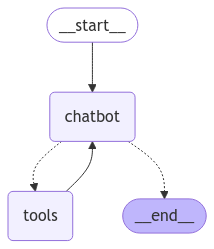

In [14]:
# 直接画图片
from IPython.display import Image, display
Image(app.get_graph().draw_mermaid_png())

### 4. 验证应用

In [15]:
config = {"configurable": {"thread_id": "123"}}

messages = [HumanMessage(content="查询深圳天气?")]

In [16]:
last_state = app.invoke({"messages": messages}, config=config)
print(last_state["messages"][-1].content)

根据提供的信息，我们可以进行以下解读和汇总：

### 气候预测：
- **温度**：2025年2月15日当天，上午11:21的天气更新显示，大部分地区的气温在16/24°C之间。
- **详细区域预报**：
  - 高原地区：气温变化为21/28°C
  - 五边形（可能是指五大洲）地区：变暖至0/12°C
  - 大城市地区：温度上升到6/16°C
  - 风信子区域：温度降至4/17°C
  - 湖泊地区：温度升高到3/8°C

### 其他信息：
- **区域**：提到的是中国境内。
- **日期与时间**：2025年2月15日的更新时间。

### 注意事项：
- 提醒读者注意不同地区的天气变化，特别是温度差异较大的地区。

如果需要进一步的具体建议或调整，请提供具体的地点和需求。例如：

- 您是否需要更详细的当地天气预报？
- 是否有关于特定活动的穿衣建议？

请告知具体需求以便我能更好地帮助您！


### 5. 整合为持续聊天机器人

In [17]:
# 编写对话循环
thread_id = "123"

while True:
    input_value = input("User: ")
    if input_value.lower() in ["quit", "再见", "exit", "q", ".exit", ".quit"]:
        print("Exit!\n")
        break
    # 把消息发给模型：记得传递config，tread_id不同，就是不同的会话
    for event in app.stream({"messages": HumanMessage(content=input_value)}, config={"configurable": {"thread_id": thread_id}}):
        # print(event)
        for value in event.values():
            if messages := value.get("messages", []):
                if isinstance(messages[-1], AIMessage):
                    print("Assistant: \n \t", messages[-1].content)
                else:
                    print("\n\t{}...\n".format(type(messages[-1])))
    print("\n")

User:  你好，我是alex, 你是？


Assistant: 
 	 你好，Alex！我叫Qwen，是由阿里云开发的一个智能助手。很高兴能为你服务，有什么问题或需要帮助的吗？




User:  你能做什么


Assistant: 
 	 当然可以，Qwen作为智能助手，能够帮助你完成许多任务。以下是一些我能做的事情：

1. **信息查询**：我可以帮你查找新闻、天气预报、航班信息等。
2. **知识问答**：无论是科技、文化、历史还是日常生活常识，我都能尽力提供准确的答案。
3. **提醒和日程管理**：你可以让我帮助你设置闹钟或提醒事项，并且可以与你的日历同步。
4. **语言翻译**：我可以帮你进行多种语言之间的翻译。
5. **教育辅导**：在某些领域内，我能提供学习资料、解释概念等。

具体来说，如果你有任何问题或者需要任何帮助，请告诉我！我会尽力协助你。




User:  我是谁


Assistant: 
 	 你是Alex，这是你在对话中告诉我的。有什么特定的问题或需要帮助的吗？例如，你想要了解一些天气信息、新闻动态，还是有其他需求呢？




User:  再见


Exit!

